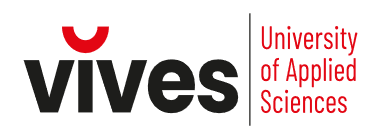<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **OUR SECOND NEURAL NETWORK IN KERAS**

We can also train a perceptron or logistic regression model with an artificial neural network. Like linear regression, perceptron and logistic regression are single-neuron networks. With perceptron and logistic regression, you do need to define an activation function for that neuron: the Heaviside step function in case of perceptron and sigmoid function in case of logistic regression.

In this notebook, we demonstrate this by fitting our "covid" dataset using [Keras](https://keras.io/), a Python interface for Deep Learning, which uses TensorFlow, Google Brain's Machine Learning library. In the Deep Learning course, we will delve deeper into neural networks and we will also use Keras there.

We only demonstrate logistic regression, because according to the Keras [documentation](https://keras.io/api/layers/activations/#available-activations), the Heaviside function is not available in Keras by default. You can define and add it yourself, but that is too advanced, so we will just use the sigmoid function, which is built in as standard, so that we can apply logistic regression.

## The Covid dataset

We read in the "Covid" dataset as Pandas DataFrame:

In [15]:
import pandas as pd

covid = pd.read_csv("covid.csv", sep=";")
covid.head()

,Patient (P),Cough (C),Fever (F),Difficulty breathing (B),Tiredness (T),Diagnosis (D)
0,1,NaN,X,X,X,sick
1,2,X,X,NaN,X,sick
2,3,X,NaN,X,X,sick
3,4,X,X,X,NaN,sick
4,5,X,NaN,NaN,X,healthy


We extract the features and the column with labels:

In [17]:
import numpy as np

X = covid[covid.columns[1:-1]].values
X[X=="X"] = 1
X = X.astype(float)
X[np.isnan(X)] = 0

y = (covid[covid.columns[-1]] == "sick").values.astype(int)

print(X)
print()
print(y)

[[0. 1. 1. 1.]
 [1. 1. 0. 1.]
 [1. 0. 1. 1.]
 [1. 1. 1. 0.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

[1 1 1 1 0 0 0 0]


Keras models expect 2D arrays as input: the rows are the number of samples, the columns are the features.

In [18]:
y = y[:, np.newaxis]

## Define Keras `Sequential` model

For logistic regression we need a neural network with only one neuron. In Keras we define a `Sequential` model with 1 `Dense` layer containing 1 node. The layer has as `activation` the `'sigmoid'` function.

In [19]:
from tensorflow import keras
from keras import Sequential, layers

model = Sequential() # Sequential is a class we need to instantiate
model.add(layers.Dense(1, activation='sigmoid')) # with add we can add a Dense layer with 1 node and sigmoid function

## Compile Keras model

During the compilation of the model we specify the optimizer. We take Stochastic Gradient Descent (SGD) with learning rate equal to 0.1. We also need to specify a loss function; we choose the log loss or `binary_crossentropy`.

In [20]:
sgd = keras.optimizers.SGD(learning_rate=0.1) # SGD is also a class we need to instantiate
model.compile(optimizer=sgd, loss="binary_crossentropy")

## Keras model training

Just like in Scikit-Learn, you have to call the `fit` method of the Keras model object to train it. The first two arguments are of course the examples and labels. We also specify the batch size, which we set equal to 1 here, which means that the model will go through the data points one by one. We also specify the number of epochs. The `fit` method returns a `History` object in which we can find, among other things, the values of the loss function after each epoch.

In [21]:
history = model.fit(X, y, batch_size=1, epochs=1000, verbose=0);  # verbose=0 suppresses the output

Let's plot the loss as a function of the number of epochs:

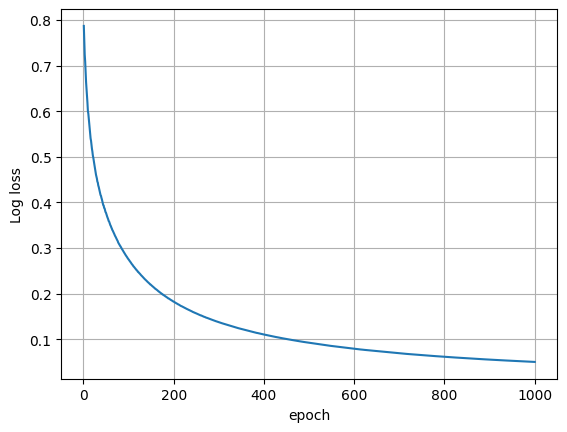

In [22]:
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs = np.arange(1, len(loss)+1)
plt.plot(epochs, loss);
plt.xlabel('epoch');
plt.ylabel('Log loss');
plt.grid();

We see that the loss function is getting smaller and smaller. Because logistic regression has probabilities as output, it never becomes zero!

In a neural network, the parameters are also called weights. We can find them in the attribute `weights` of our model object. In this case, the second weight is the intercept, which is called "bias" here. The weights are stored as TensorFlow variables. With the method `numpy` we can convert them to NumPy arrays.

In [23]:
model.weights[0].numpy().flatten() # weights

array([5.2804475, 5.2507987, 5.27968  , 5.2512074], dtype=float32)

There are 4 weights because we have 4 features.

In [24]:
model.weights[1].numpy()[0] # bias

np.float32(-12.662522)

## Making predictions

Just like in Scikit-Learn, the `Sequential` object has a method `predict` that allows us to make predictions. But in this case, we get probabilities!

In [26]:
prob = model.predict(X, verbose=0)
prob

array([[9.5767635e-01],
       [9.5770746e-01],
       [9.5886189e-01],
       [9.5884579e-01],
       [1.0613263e-01],
       [1.0602112e-01],
       [6.0376374e-04],
       [6.0401030e-04]], dtype=float32)

We need to round these probabilities to get the predicted labels:

In [27]:
y_pred = np.round(prob)
y_pred

array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

Checking whether they are indeed the same as the labels:

In [28]:
y_pred == y

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

Yes! All labels are predicted correctly!

Is someone who just coughs sick?

In [30]:
new_patient = np.array([[1., 0., 0., 0.]])  # must be 2D!
model.predict(new_patient, verbose=0)[0, 0]

np.float32(0.0006219213)

So there is a very small chance that this patient is sick...

---